In [3]:
from matplotlib import pyplot as plt
from itertools import product
# import seaborn as sns
import pandas as pd
import pingouin as pg
import os.path as op
import argparse
import re
import numpy as np
import matplotlib.pyplot as plt
import mne
import seaborn as sns
from scipy import signal, stats
from scipy.fft import fftshift
from bids import BIDSLayout
from statsmodels.stats.anova import AnovaRM

from util.io.ffr import *
palette_tab10 = sns.color_palette("tab10", 10)

In [4]:
# Load accuracies
accuracies = pd.read_csv('accuracy.csv')

In [5]:
# Load ERPs
evokeds = pd.read_csv('evokeds.csv')
evokeds

,sub,chan,target,accuracy,tone,msec,uV
0,3,Cz,1,low,1,-273,-0.079743
1,3,Cz,1,low,1,-272,-0.093544
2,3,Cz,1,low,1,-271,-0.106012
3,3,Cz,1,low,1,-270,-0.116212
4,3,Cz,1,low,1,-269,-0.124180
...,...,...,...,...,...,...,...
1403995,42,Pz,3,low,3,522,0.838061
1403996,42,Pz,3,low,3,523,0.838007
1403997,42,Pz,3,low,3,524,0.836003
1403998,42,Pz,3,low,3,525,0.833778


In [6]:
# Rename target and tone vars to freq
mapping = {1: 130,
           2: 200,
           3: 280}

evokeds['target'] = evokeds['target'].replace(mapping)
evokeds['tone'] = evokeds['tone'].replace(mapping)
# evokeds

In [7]:
# Adjust EEG units
# evokeds['uV'] = evokeds['uV'] * 1000000 - 0.30
# evokeds

In [8]:
# Adjust EEG timing according to lag
evokeds['msec'] = evokeds['msec'] - 27

In [9]:
# Split data up for analyses
evokeds_Cz = evokeds[evokeds.chan == 'Cz']
evokeds_tone_1 = evokeds_Cz[evokeds_Cz.tone == 130]
evokeds_tone_2 = evokeds_Cz[evokeds_Cz.tone == 200]
evokeds_tone_3 = evokeds_Cz[evokeds_Cz.tone == 280]

# Tests on mean amplitudes

#### N1 (mean value from 100-200 msec)

In [32]:
seg = evokeds_Cz[evokeds_Cz.msec > 100]
seg = seg[seg.msec < 200]

                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
tone         0.4390 2.0000  76.0000 0.6463
target       3.6032 2.0000  76.0000 0.0320
tone:target  1.1136 4.0000 152.0000 0.3523



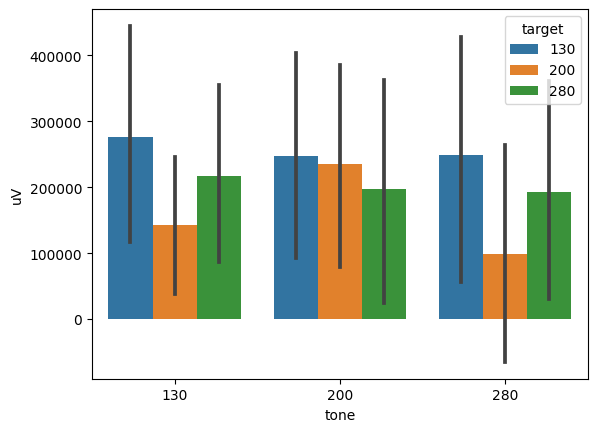

In [33]:
# By target
seg_target = seg.groupby(['sub', 'tone', 'target'], as_index=False)['uV'].mean()
sns.barplot(seg_target, x="tone", y="uV", hue="target")
aov = AnovaRM(
    data = seg_target, 
    depvar = 'uV',
    subject = 'sub', 
    within = ['tone', 'target']
)
res = aov.fit()
print(res)


ANOVA SUMMARY

Source                     SS    DF1    DF2                MS      F    p-unc    p-GG-corr    np2      eps    sphericity    W-spher    p-spher
-----------  ----------------  -----  -----  ----------------  -----  -------  -----------  -----  -------  ------------  ---------  ---------
accuracy     938677105126.153      1     37  938677105126.153  1.695    0.201      nan      0.044  nan           nan        nan        nan
tone          44385260386.912      2     74   22192630193.456  0.491    0.614        0.597  0.013    0.779         0.000      0.716      0.002
Interaction  495110427768.957      2     74  247555213884.479  5.474    0.006      nan      0.129  nan           nan        nan        nan



/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/pingouin/parametric.py:1574: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  aov = pd.concat([aov_betw.drop(1), aov_with.drop(1)], axis=0, sort=False, ignore_index=True)


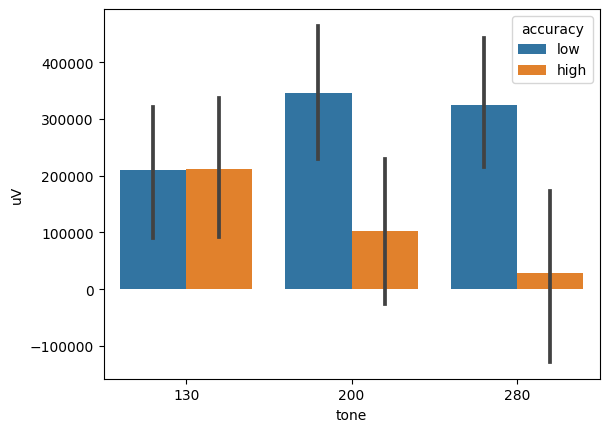

In [34]:
# By target and accuracy
seg_accuracy = seg.groupby(['sub', 'tone', 'target', 'accuracy'], as_index=False)['uV'].mean()
sns.barplot(seg_accuracy, x="tone", y="uV", hue="accuracy")
aov = seg_accuracy.mixed_anova(dv='uV', within='tone', between='accuracy', subject='sub')
pg.print_table(aov)

In [35]:
# Save data to run ANOVA on Jamovi
seg = seg.groupby(['sub', 'tone', 'target', 'accuracy'], as_index=False)['uV'].mean()
seg.to_csv('N1.csv', index = False)

#### P2 (mean value from 200-230 msec)

In [10]:
seg = evokeds_Cz[evokeds_Cz.msec > 200]
seg = seg[seg.msec < 230]

                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
tone         9.1850 2.0000  76.0000 0.0003
target       1.8785 2.0000  76.0000 0.1598
tone:target 16.9944 4.0000 152.0000 0.0000



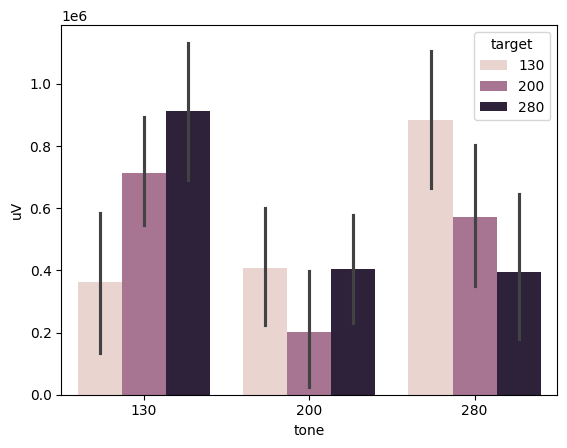

In [11]:
# By target
seg_target = seg.groupby(['sub', 'tone', 'target'], as_index=False)['uV'].mean()
sns.barplot(seg_target, x="tone", y="uV", hue="target")
aov = AnovaRM(
    data = seg_target, 
    depvar = 'uV',
    subject = 'sub', 
    within = ['tone', 'target']
)
res = aov.fit()
print(res)


ANOVA SUMMARY

Source                      SS    DF1    DF2                 MS      F    p-unc    np2      eps
-----------  -----------------  -----  -----  -----------------  -----  -------  -----  -------
accuracy      786370083354.360      1     37   786370083354.360  0.948    0.337  0.025  nan
tone         2402183315814.361      2     74  1201091657907.181  9.591    0.000  0.206    0.982
Interaction   671211057913.688      2     74   335605528956.844  2.680    0.075  0.068  nan



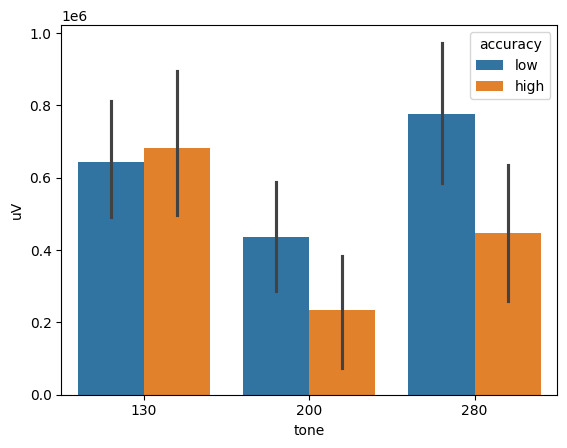

In [12]:
# By target and accuracy
seg_accuracy = seg.groupby(['sub', 'tone', 'target', 'accuracy'], as_index=False)['uV'].mean()
sns.barplot(seg_accuracy, x="tone", y="uV", hue="accuracy")
aov = seg_accuracy.mixed_anova(dv='uV', within='tone', between='accuracy', subject='sub')
pg.print_table(aov)

In [13]:
# Save data to run ANOVA on Jamovi
seg = seg.groupby(['sub', 'tone', 'target', 'accuracy'], as_index=False)['uV'].mean()
seg.to_csv('P2.csv', index = False)

#### N2 (mean value from 250-360 msec)

In [39]:
seg = evokeds_Cz[evokeds_Cz.msec > 250]
seg = seg[seg.msec < 360]

                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
tone        11.1636 2.0000  76.0000 0.0001
target       7.8588 2.0000  76.0000 0.0008
tone:target  2.1540 4.0000 152.0000 0.0769



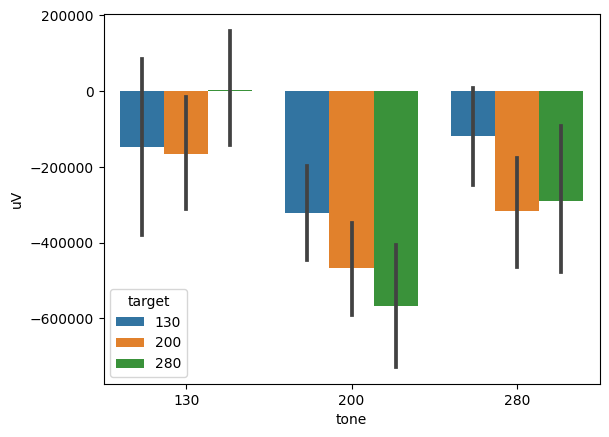

In [40]:
# By target
seg_target = seg.groupby(['sub', 'tone', 'target'], as_index=False)['uV'].mean()
sns.barplot(seg_target, x="tone", y="uV", hue="target")
aov = AnovaRM(
    data = seg_target, 
    depvar = 'uV',
    subject = 'sub', 
    within = ['tone', 'target']
)
res = aov.fit()
print(res)

In [41]:
# Save data to run ANOVA on Jamovi
seg = seg.groupby(['sub', 'tone', 'target', 'accuracy'], as_index=False)['uV'].mean()
seg.to_csv('N2.csv', index = False)


ANOVA SUMMARY

Source                      SS    DF1    DF2                 MS       F    p-unc    p-GG-corr    np2      eps    sphericity    W-spher    p-spher
-----------  -----------------  -----  -----  -----------------  ------  -------  -----------  -----  -------  ------------  ---------  ---------
accuracy      415410736969.033      1     37   415410736969.033   1.669    0.204      nan      0.043  nan           nan        nan        nan
tone         2408491775105.933      2     74  1204245887552.966  11.140    0.000        0.000  0.231    0.836         0.000      0.803      0.017
Interaction   198491624306.113      2     74    99245812153.057   0.918    0.404      nan      0.024  nan           nan        nan        nan



/project/hcn1/.conda/envs/mne/lib/python3.11/site-packages/pingouin/parametric.py:1574: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  aov = pd.concat([aov_betw.drop(1), aov_with.drop(1)], axis=0, sort=False, ignore_index=True)


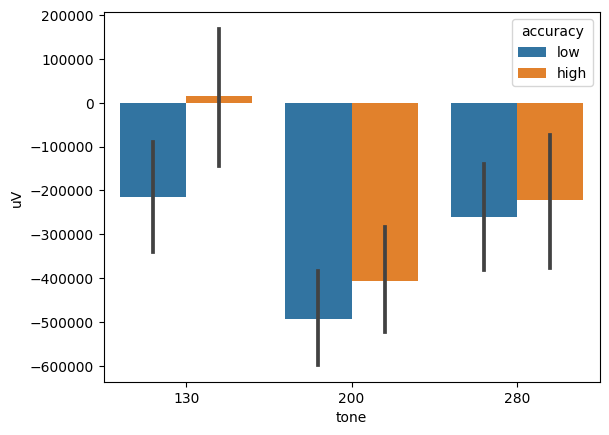

In [42]:
# By target and accuracy
seg_accuracy = seg.groupby(['sub', 'tone', 'target', 'accuracy'], as_index=False)['uV'].mean()
sns.barplot(seg_accuracy, x="tone", y="uV", hue="accuracy")
aov = seg_accuracy.mixed_anova(dv='uV', within='tone', between='accuracy', subject='sub')
pg.print_table(aov)

#### P4 (mean value from 360-420 msec)

In [39]:
seg = evokeds_Cz[evokeds_Cz.msec > 380]
seg = seg[seg.msec < 440]

                  Anova
            F Value Num DF  Den DF  Pr > F
------------------------------------------
tone         0.4481 2.0000  76.0000 0.6405
target      10.3274 2.0000  76.0000 0.0001
tone:target  3.3553 4.0000 152.0000 0.0115



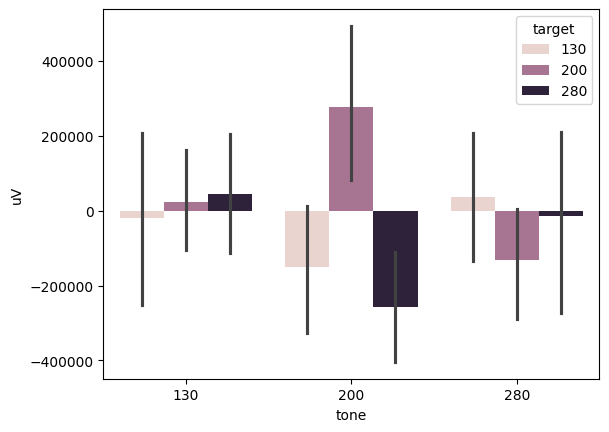

In [40]:
# By target
seg_target = seg.groupby(['sub', 'tone', 'target'], as_index=False)['uV'].mean()
sns.barplot(seg_target, x="tone", y="uV", hue="target")
aov = AnovaRM(
    data = seg_target, 
    depvar = 'uV',
    subject = 'sub', 
    within = ['tone', 'target']
)
res = aov.fit()
print(res)

In [41]:
# Save data to run ANOVA on Jamovi
seg = seg.groupby(['sub', 'tone', 'target', 'accuracy'], as_index=False)['uV'].mean()
seg.to_csv('P4.csv', index = False)


ANOVA SUMMARY

Source                     SS    DF1    DF2                MS      F    p-unc    np2      eps
-----------  ----------------  -----  -----  ----------------  -----  -------  -----  -------
accuracy      28159677113.945      1     37   28159677113.945  0.099    0.755  0.003  nan
tone          82259516307.698      2     74   41129758153.849  0.464    0.631  0.012    0.911
Interaction  415844138276.617      2     74  207922069138.309  2.345    0.103  0.060  nan



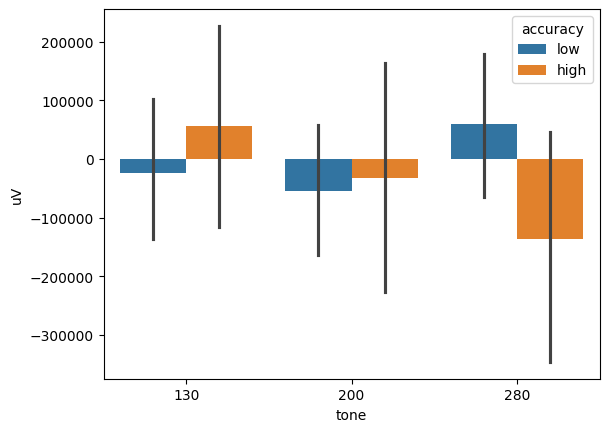

In [42]:
# By target and accuracy
seg_accuracy = seg.groupby(['sub', 'tone', 'target', 'accuracy'], as_index=False)['uV'].mean()
sns.barplot(seg_accuracy, x="tone", y="uV", hue="accuracy")
aov = seg_accuracy.mixed_anova(dv='uV', within='tone', between='accuracy', subject='sub')
pg.print_table(aov)

# Latencies

In [55]:
mean_evokeds = evokeds[evokeds.chan == 'Cz']
mean_evokeds_tone = mean_evokeds.groupby(['chan', 'tone', 'msec'], as_index=False)['uV'].mean()
mean_evokeds_target = mean_evokeds.groupby(['chan', 'target', 'tone', 'msec'], as_index=False)['uV'].mean()
mean_evokeds_target

,chan,target,tone,msec,uV
0,Cz,130,130,-300,197869.991843
1,Cz,130,130,-299,190982.905504
2,Cz,130,130,-298,183703.313830
3,Cz,130,130,-297,176364.915984
4,Cz,130,130,-296,168933.757936
...,...,...,...,...,...
7195,Cz,280,280,495,177815.380264
7196,Cz,280,280,496,172707.335307
7197,Cz,280,280,497,167394.012906
7198,Cz,280,280,498,162031.597217


#### Min at 100-200 msec

In [56]:
seg_tone = mean_evokeds_tone[mean_evokeds_tone.msec > 100]
seg_tone = seg_tone[seg_tone.msec < 200]

# # Tone 1
tmp = seg_tone[(seg_tone.tone == 130)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 1: {lat}')
# # Tone 2
tmp = seg_tone[(seg_tone.tone == 200)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 2: {lat}')
# # Tone 3
tmp = seg_tone[(seg_tone.tone == 280)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 3: {lat}')

seg_target = mean_evokeds_target[mean_evokeds_target.msec > 100]
seg_target = seg_target[seg_target.msec < 200]

# Tone 1 when tone 1 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 1, target 1: {lat}')
# Tone 1 when tone 2 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 1, target 2: {lat}')
# Tone 1 when tone 3 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 1, target 3: {lat}')

# Tone 2 when tone 1 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 2, target 1: {lat}')
# Tone 2 when tone 2 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 2, target 2: {lat}')
# Tone 2 when tone 3 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 2, target 3: {lat}')

# Tone 3 when tone 1 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 3, target 1: {lat}')
# Tone 3 when tone 2 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 3, target 2: {lat}')
# Tone 3 when tone 3 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 3, target 3: {lat}')

Latency of min tone 1: 132
Latency of min tone 2: 131
Latency of min tone 3: 128
Latency of min tone 1, target 1: 130
Latency of min tone 1, target 2: 134
Latency of min tone 1, target 3: 132
Latency of min tone 2, target 1: 131
Latency of min tone 2, target 2: 133
Latency of min tone 2, target 3: 130
Latency of min tone 3, target 1: 127
Latency of min tone 3, target 2: 129
Latency of min tone 3, target 3: 127


#### Max at 200-230 msec

In [57]:
seg_tone = mean_evokeds_tone[mean_evokeds_tone.msec > 200]
seg_tone = seg_tone[seg_tone.msec < 230]

# # Tone 1
tmp = seg_tone[(seg_tone.tone == 130)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 1: {lat}')
# # Tone 2
tmp = seg_tone[(seg_tone.tone == 200)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 2: {lat}')
# # Tone 3
tmp = seg_tone[(seg_tone.tone == 280)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 3: {lat}')

seg_target = mean_evokeds_target[mean_evokeds_target.msec > 200]
seg_target = seg_target[seg_target.msec < 230]

# Tone 1 when tone 1 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 1, target 1: {lat}')
# Tone 1 when tone 2 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 1, target 2: {lat}')
# Tone 1 when tone 3 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 1, target 3: {lat}')

# Tone 2 when tone 1 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 2, target 1: {lat}')
# Tone 2 when tone 2 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 2, target 2: {lat}')
# Tone 2 when tone 3 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 2, target 3: {lat}')

# Tone 3 when tone 1 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 3, target 1: {lat}')
# Tone 3 when tone 2 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 3, target 2: {lat}')
# Tone 3 when tone 3 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == max(tmp.uV)])
print(f'Latency of max tone 3, target 3: {lat}')

Latency of max tone 1: 204
Latency of max tone 2: 201
Latency of max tone 3: 201
Latency of max tone 1, target 1: 201
Latency of max tone 1, target 2: 210
Latency of max tone 1, target 3: 207
Latency of max tone 2, target 1: 201
Latency of max tone 2, target 2: 201
Latency of max tone 2, target 3: 201
Latency of max tone 3, target 1: 213
Latency of max tone 3, target 2: 201
Latency of max tone 3, target 3: 201


#### Min at 250-360 msec (important)

In [58]:
seg_tone = mean_evokeds_tone[mean_evokeds_tone.msec > 250]
seg_tone = seg_tone[seg_tone.msec < 360]

# # Tone 1
tmp = seg_tone[(seg_tone.tone == 130)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 1: {lat}')
# # Tone 2
tmp = seg_tone[(seg_tone.tone == 200)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 2: {lat}')
# # Tone 3
tmp = seg_tone[(seg_tone.tone == 280)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 3: {lat}')

seg_target = mean_evokeds_target[mean_evokeds_target.msec > 250]
seg_target = seg_target[seg_target.msec < 360]

# Tone 1 when tone 1 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 1, target 1: {lat}')
# Tone 1 when tone 2 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 1, target 2: {lat}')
# Tone 1 when tone 3 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 1, target 3: {lat}')

# Tone 2 when tone 1 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 2, target 1: {lat}')
# Tone 2 when tone 2 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 2, target 2: {lat}')
# Tone 2 when tone 3 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 2, target 3: {lat}')

# Tone 3 when tone 1 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 130)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 3, target 1: {lat}')
# Tone 3 when tone 2 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 200)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 3, target 2: {lat}')
# Tone 3 when tone 3 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 280)]
lat = int(tmp.msec[tmp.uV == min(tmp.uV)])
print(f'Latency of min tone 3, target 3: {lat}')

Latency of min tone 1: 351
Latency of min tone 2: 332
Latency of min tone 3: 339
Latency of min tone 1, target 1: 351
Latency of min tone 1, target 2: 350
Latency of min tone 1, target 3: 351
Latency of min tone 2, target 1: 343
Latency of min tone 2, target 2: 302
Latency of min tone 2, target 3: 327
Latency of min tone 3, target 1: 334
Latency of min tone 3, target 2: 343
Latency of min tone 3, target 3: 334


#### Inflection point

In [59]:
seg_tone = mean_evokeds_tone[mean_evokeds_tone.msec > 360]
seg_tone = seg_tone[seg_tone.msec < 420]

# # Tone 1
tmp = seg_tone[(seg_tone.tone == 130)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 1: {inflection}')
# # Tone 2
tmp = seg_tone[(seg_tone.tone == 200)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 2: {inflection}')
# # Tone 3
tmp = seg_tone[(seg_tone.tone == 280)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 3: {inflection}')

seg_target = mean_evokeds_target[mean_evokeds_target.msec > 360]
seg_target = seg_target[seg_target.msec < 420]

# Tone 1 when tone 1 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 130)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 1, target 1: {inflection}')
# Tone 1 when tone 2 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 200)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 1, target 2: {inflection}')
# Tone 1 when tone 3 is target
tmp = seg_target[(seg_target.tone == 130) & (seg_target.target == 280)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 1, target 3: {inflection}')

# Tone 2 when tone 1 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 130)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 2, target 1: {inflection}')
# Tone 2 when tone 2 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 200)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 2, target 2: {inflection}')
# Tone 2 when tone 3 is target
tmp = seg_target[(seg_target.tone == 200) & (seg_target.target == 280)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 2, target 3: {inflection}')

# Tone 3 when tone 1 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 130)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 3, target 1: {inflection}')
# Tone 3 when tone 2 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 200)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 3, target 2: {inflection}')
# Tone 3 when tone 3 is target
tmp = seg_target[(seg_target.tone == 280) & (seg_target.target == 280)]
dy = np.diff(tmp.uV, n = 1)
idx = np.abs(dy).argmin()
inflection = tmp.msec.tolist()[idx]
print(f'Latency of inflection tone 3, target 3: {inflection}')

Latency of inflection tone 1: 374
Latency of inflection tone 2: 393
Latency of inflection tone 3: 398
Latency of inflection tone 1, target 1: 375
Latency of inflection tone 1, target 2: 374
Latency of inflection tone 1, target 3: 375
Latency of inflection tone 2, target 1: 391
Latency of inflection tone 2, target 2: 414
Latency of inflection tone 2, target 3: 391
Latency of inflection tone 3, target 1: 392
Latency of inflection tone 3, target 2: 395
Latency of inflection tone 3, target 3: 402


## Tests on latencies

In [52]:
evokeds

,sub,chan,target,accuracy,tone,msec,uV
0,3,Cz,130,low,130,-300,-79743.214406
1,3,Cz,130,low,130,-299,-93543.903250
2,3,Cz,130,low,130,-298,-106012.615886
3,3,Cz,130,low,130,-297,-116212.246897
4,3,Cz,130,low,130,-296,-124179.984197
...,...,...,...,...,...,...,...
1403995,42,Pz,280,low,280,495,838060.590563
1403996,42,Pz,280,low,280,496,838006.698345
1403997,42,Pz,280,low,280,497,836002.304171
1403998,42,Pz,280,low,280,498,833777.420562


In [64]:
# predictability = [True, False]

# def get_latencies_tone(evokeds, start, end, peak_type):
#     all_lat = []
#     tones = [130, 200, 280]
#     for sub in np.unique(evokeds['sub']):
#         for tone in tones:
#             evokeds_cz = evokeds[evokeds.chan == 'Cz']
#             evokeds_sub = evokeds_cz[evokeds_cz['sub'] == sub]
#             seg = evokeds_sub[evokeds_sub.msec > start]
#             seg = seg[seg.msec < end]
#             seg = seg[seg.tone == tone]
#             if peak_type == 'min':
#                 peak = min(seg.uV)
#             elif peak_type == 'max':
#                 peak = max(seg.uV)
#             elif peak_type == 'infl':
#                 dy = np.diff(seg.uV, n = 1)
#                 idx = np.abs(dy).argmin()
#                 peak = seg.uV.tolist()[idx]
#                 lat = seg.msec.tolist()[idx]
#             lat = int(seg.msec[seg.uV == peak])
#             df = pd.DataFrame({
#                 'sub': [sub],
#                 'start': [start],
#                 'end': [end],
#                 'tone': [tone],
#                 'peak_type': [peak_type],
#                 'peak': [peak],
#                 'latency': [lat],
#             })
#             all_lat.append(df)
#     all_lat = pd.concat(all_lat)
#     return all_lat
    
def get_latencies_target(evokeds, start, end, peak_type):
    all_lat = []
    tones = [130, 200, 280]
    for sub in np.unique(evokeds['sub']):
        for tone in tones:
            for target in tones:
                evokeds_cz = evokeds[evokeds.chan == 'Cz']
                evokeds_sub = evokeds_cz[evokeds_cz['sub'] == sub]
                seg = evokeds_sub[evokeds_sub.msec > start]
                seg = seg[seg.msec < end]
                seg = seg[(seg.tone == tone) & (seg.target == target)]
                if peak_type == 'min':
                    peak = min(seg.uV)
                elif peak_type == 'max':
                    peak = max(seg.uV)
                elif peak_type == 'infl':
                    dy = np.diff(seg.uV, n = 1)
                    idx = np.abs(dy).argmin()
                    peak = seg.uV.tolist()[idx]
                    lat = seg.msec.tolist()[idx]
                lat = int(seg.msec[seg.uV == peak])
                df = pd.DataFrame({
                    'sub': [sub],
                    'start': [start],
                    'end': [end],
                    'tone': [tone],
                    'target': [target],
                    'peak_type': [peak_type],
                    'peak': [peak],
                    'latency': [lat],
                })
                all_lat.append(df)
    all_lat = pd.concat(all_lat)
    return all_lat
    
def get_latencies(evokeds, start, end, peak_type):
    all_lat = []
    tones = [130, 200, 280]
    for sub in np.unique(evokeds['sub']):
        for tone in tones:
            for target in tones:
                evokeds_cz = evokeds[evokeds.chan == 'Cz']
                evokeds_sub = evokeds_cz[evokeds_cz['sub'] == sub]
                accuracy = np.unique(evokeds_sub.accuracy).tolist()
                seg = evokeds_sub[evokeds_sub.msec > start]
                seg = seg[seg.msec < end]
                seg = seg[(seg.tone == tone) & (seg.target == target)]
                if peak_type == 'min':
                    peak = min(seg.uV)
                elif peak_type == 'max':
                    peak = max(seg.uV)
                elif peak_type == 'infl':
                    dy = np.diff(seg.uV, n = 1)
                    idx = np.abs(dy).argmin()
                    peak = seg.uV.tolist()[idx]
                    lat = seg.msec.tolist()[idx]
                lat = int(seg.msec[seg.uV == peak])
                df = pd.DataFrame({
                    'sub': [sub],
                    'start': [start],
                    'end': [end],
                    'tone': [tone],
                    'target': [target],
                    'accuracy': accuracy,
                    'peak_type': [peak_type],
                    'peak': [peak],
                    'latency': [lat],
                })
                all_lat.append(df)
    all_lat = pd.concat(all_lat)
    return all_lat

#### Min at 100-200 msec

In [65]:
# latencies_tone = get_latencies_tone(evokeds, 100, 200, 'min')
# sns.barplot(latencies_tone, x = "tone", y = "latency")

<Axes: xlabel='tone', ylabel='latency'>

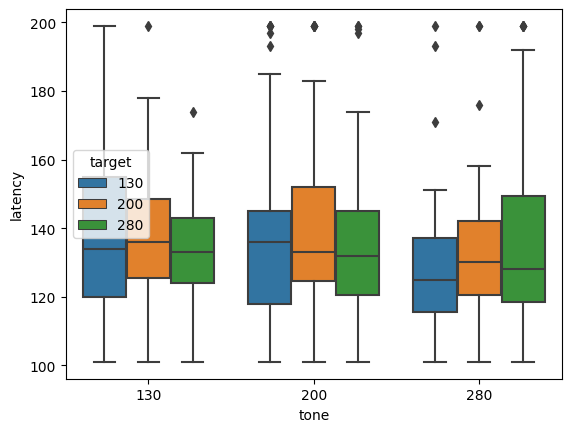

In [66]:
latencies_target = get_latencies_target(evokeds, 100, 200, 'min')
sns.boxplot(latencies_target, x = "tone", y = "latency", hue = "target")

In [67]:
# Save data to run ANOVA on Jamovi
latencies = get_latencies(evokeds, 100, 200, 'min')
latencies.to_csv('N1-latencies.csv', index = False)

#### Max at 200-230 msec

In [68]:
# latencies_tone = get_latencies_tone(evokeds, 200, 230, 'max')
# sns.barplot(latencies_tone, x = "tone", y = "latency")

<Axes: xlabel='tone', ylabel='latency'>

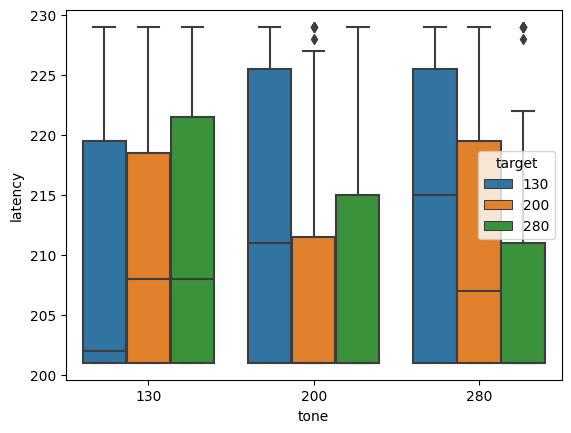

In [69]:
latencies_target = get_latencies_target(evokeds, 200, 230, 'max')
sns.boxplot(latencies_target, x = "tone", y = "latency", hue = "target")

In [70]:
# Save data to run ANOVA on Jamovi
latencies = get_latencies(evokeds, 200, 230, 'max')
latencies.to_csv('P2-latencies.csv', index = False)

#### Min at 250-360 msec 

In [71]:
# latencies_tone = get_latencies_tone(evokeds, 250, 360, 'min')
# sns.barplot(latencies_tone, x = "tone", y = "latency")

<Axes: xlabel='tone', ylabel='latency'>

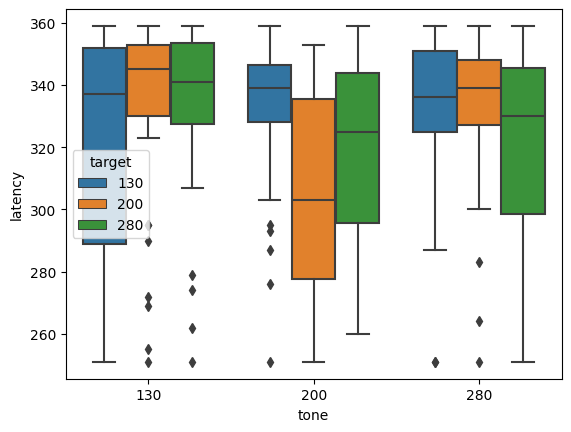

In [72]:
latencies_target = get_latencies_target(evokeds, 250, 360, 'min')
sns.boxplot(latencies_target, x = "tone", y = "latency", hue = "target")

In [73]:
# Save data to run ANOVA on Jamovi
latencies = get_latencies(evokeds, 250, 360, 'min')
latencies.to_csv('N2-latencies.csv', index = False)

#### Inflection at 360-420 msec

In [74]:
# latencies_tone = get_latencies_tone(evokeds, 360, 420, 'infl')
# sns.boxplot(latencies_tone, x = "tone", y = "latency")

<Axes: xlabel='tone', ylabel='latency'>

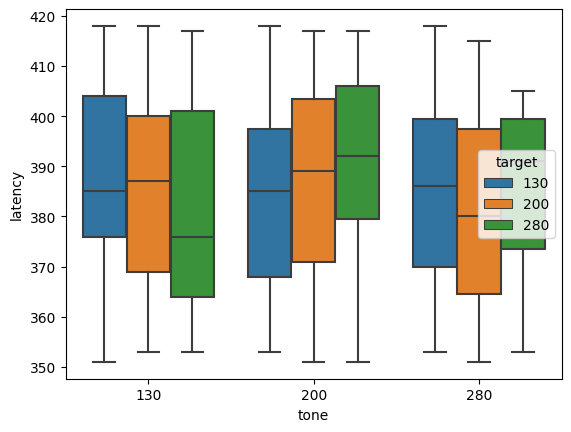

In [75]:
latencies_target = get_latencies_target(evokeds, 350, 420, 'infl')
sns.boxplot(latencies_target, x = "tone", y = "latency", hue = "target")

In [76]:
# Save data to run ANOVA on Jamovi
latencies = get_latencies(evokeds, 350, 420, 'infl')
latencies.to_csv('P4-latencies.csv', index = False)

### Peaks

In [ ]:
mean_evokeds_predictable = mean_evokeds.groupby(['sub', 'tone', 'predictable', 'msec'], as_index=False)['uV'].mean()

#### Max at 80-130 msec

In [ ]:
seg = mean_evokeds_predictable[mean_evokeds_predictable.msec > 80]
seg = seg[seg.msec < 130]

# Tone 1
seg_1 = seg[seg.tone == 130]
print(f'Max for predictable tone 1: {max(seg_1.uV[seg_1.predictable == True])}')
print(f'Max for unpredictable tone 1: {max(seg_1.uV[seg_1.predictable == False])}')

# Tone 2
seg_2 = seg[seg.tone == 200]
print(f'Max for predictable tone 2: {max(seg_2.uV[seg_2.predictable == True])}')
print(f'Max for unpredictable tone 2: {max(seg_2.uV[seg_2.predictable == False])}')

# Tone 3
seg_3 = seg[seg.tone == 280]
print(f'Max for predictable tone 3: {max(seg_3.uV[seg_3.predictable == True])}')
print(f'Max for unpredictable tone 3: {max(seg_3.uV[seg_3.predictable == False])}')

# Plot
seg = seg.groupby(['sub', 'tone', 'predictable'], as_index = False)['uV'].max()
sns.barplot(seg, x = "tone", y = "uV", hue = "predictable")

# Test
aov = AnovaRM(
    data = seg, 
    depvar = 'uV',
    subject = 'sub', 
    within = ['predictable', 'tone']
)
res = aov.fit()
print(res)

#### Min at 100-180 msec

In [ ]:
seg = mean_evokeds_predictable[mean_evokeds_predictable.msec > 100]
seg = seg[seg.msec < 180]

# Tone 1
seg_1 = seg[seg.tone == 130]
print(f'Max for predictable tone 1: {max(seg_1.uV[seg_1.predictable == True])}')
print(f'Max for unpredictable tone 1: {max(seg_1.uV[seg_1.predictable == False])}')

# Tone 2
seg_2 = seg[seg.tone == 200]
print(f'Max for predictable tone 2: {max(seg_2.uV[seg_2.predictable == True])}')
print(f'Max for unpredictable tone 2: {max(seg_2.uV[seg_2.predictable == False])}')

# Tone 3
seg_3 = seg[seg.tone == 280]
print(f'Max for predictable tone 3: {max(seg_3.uV[seg_3.predictable == True])}')
print(f'Max for unpredictable tone 3: {max(seg_3.uV[seg_3.predictable == False])}')

# Plot
seg = seg.groupby(['sub', 'tone', 'predictable'], as_index = False)['uV'].max()
sns.barplot(seg, x = "tone", y = "uV", hue = "predictable")

# Test
aov = AnovaRM(
    data = seg, 
    depvar = 'uV',
    subject = 'sub', 
    within = ['predictable', 'tone']
)
res = aov.fit()
print(res)

#### Max at 200-280 msec

In [ ]:
seg = mean_evokeds_predictable[mean_evokeds_predictable.msec > 200]
seg = seg[seg.msec < 280]

# Tone 1
seg_1 = seg[seg.tone == 130]
print(f'Max for predictable tone 1: {max(seg_1.uV[seg_1.predictable == True])}')
print(f'Max for unpredictable tone 1: {max(seg_1.uV[seg_1.predictable == False])}')

# Tone 2
seg_2 = seg[seg.tone == 200]
print(f'Max for predictable tone 2: {max(seg_2.uV[seg_2.predictable == True])}')
print(f'Max for unpredictable tone 2: {max(seg_2.uV[seg_2.predictable == False])}')

# Tone 3
seg_3 = seg[seg.tone == 280]
print(f'Max for predictable tone 3: {max(seg_3.uV[seg_3.predictable == True])}')
print(f'Max for unpredictable tone 3: {max(seg_3.uV[seg_3.predictable == False])}')

# Plot
seg = seg.groupby(['sub', 'tone', 'predictable'], as_index = False)['uV'].max()
sns.barplot(seg, x = "tone", y = "uV", hue = "predictable")

# Test
aov = AnovaRM(
    data = seg, 
    depvar = 'uV',
    subject = 'sub', 
    within = ['predictable', 'tone']
)
res = aov.fit()
print(res)

#### Min at 250-450 msec

In [ ]:
seg = mean_evokeds_predictable[mean_evokeds_predictable.msec > 250]
seg = seg[seg.msec < 450]

# Tone 1
seg_1 = seg[seg.tone == 130]
print(f'Max for predictable tone 1: {max(seg_1.uV[seg_1.predictable == True])}')
print(f'Max for unpredictable tone 1: {max(seg_1.uV[seg_1.predictable == False])}')

# Tone 2
seg_2 = seg[seg.tone == 200]
print(f'Max for predictable tone 2: {max(seg_2.uV[seg_2.predictable == True])}')
print(f'Max for unpredictable tone 2: {max(seg_2.uV[seg_2.predictable == False])}')

# Tone 3
seg_3 = seg[seg.tone == 280]
print(f'Max for predictable tone 3: {max(seg_3.uV[seg_3.predictable == True])}')
print(f'Max for unpredictable tone 3: {max(seg_3.uV[seg_3.predictable == False])}')

# Plot
seg = seg.groupby(['sub', 'tone', 'predictable'], as_index = False)['uV'].max()
sns.barplot(seg, x = "tone", y = "uV", hue = "predictable")

# Test
aov = AnovaRM(
    data = seg, 
    depvar = 'uV',
    subject = 'sub', 
    within = ['predictable', 'tone']
)
res = aov.fit()
print(res)

# Peak values

In [ ]:
mean_evokeds_tone = evokeds_Cz.groupby(['tone', 'msec'], as_index=False)['uV'].mean()
mean_evokeds_target = mean_evokeds.groupby(['target', 'tone', 'msec'], as_index=False)['uV'].mean()
mean_evokeds_predictable = mean_evokeds.groupby(['tone', 'predictable', 'msec'], as_index=False)['uV'].mean()
mean_evokeds_predictable

#### P1 (max at 50-100 msec)

In [ ]:
seg_tone = mean_evokeds_tone[mean_evokeds_tone.msec > 50]
seg_tone = seg_tone[seg_tone.msec < 100]

# Tone 1
print(f'Max tone 1: {max(seg_tone.uV[seg_tone.tone == 130])}')
# Tone 2
print(f'Max tone 2: {max(seg_tone.uV[seg_tone.tone == 200])}')
# Tone 3
print(f'Max tone 3: {max(seg_tone.uV[seg_tone.tone == 280])}')

seg_target = mean_evokeds_target[mean_evokeds_target.msec > 50]
seg_target = seg_target[seg_target.msec < 100]

# Tone 1 when tone 1 is target
print(f'Max tone 1, target 1: {max(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 130)])}')
# Tone 1 when tone 2 is target
print(f'Max tone 1, target 2: {max(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 200)])}')
# Tone 1 when tone 3 is target
print(f'Max tone 1, target 3: {max(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 280)])}')
# Tone 2 when tone 1 is target
print(f'Max tone 2, target 1: {max(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 130)])}')
# Tone 2 when tone 2 is target
print(f'Max tone 2, target 2: {max(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 200)])}')
# Tone 2 when tone 3 is target
print(f'Max tone 3, target 3: {max(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 280)])}')
# Tone 3 when tone 1 is target
print(f'Max tone 3, target 1: {max(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 130)])}')
# Tone 3 when tone 2 is target
print(f'Max tone 3, target 2: {max(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 200)])}')
# Tone 3 when tone 3 is target
print(f'Max tone 3, target 3: {max(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 280)])}')

#### N1 (min at 70-200 msec)

In [ ]:
seg_tone = mean_evokeds_tone[mean_evokeds_tone.msec > 70]
seg_tone = seg_tone[seg_tone.msec < 200]

# Tone 1
print(f'Max tone 1: {min(seg_tone.uV[seg_tone.tone == 130])}')
# Tone 2
print(f'Max tone 2: {min(seg_tone.uV[seg_tone.tone == 200])}')
# Tone 3
print(f'Max tone 3: {min(seg_tone.uV[seg_tone.tone == 280])}')

seg_target = mean_evokeds_target[mean_evokeds_target.msec > 70]
seg_target = seg_target[seg_target.msec < 200]

# Tone 1 when tone 1 is target
print(f'Max tone 1, target 1: {min(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 130)])}')
# Tone 1 when tone 2 is target
print(f'Max tone 1, target 2: {min(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 200)])}')
# Tone 1 when tone 3 is target
print(f'Max tone 1, target 3: {min(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 280)])}')
# Tone 2 when tone 1 is target
print(f'Max tone 2, target 1: {min(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 130)])}')
# Tone 2 when tone 2 is target
print(f'Max tone 2, target 2: {min(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 200)])}')
# Tone 2 when tone 3 is target
print(f'Max tone 3, target 3: {min(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 280)])}')
# Tone 3 when tone 1 is target
print(f'Max tone 3, target 1: {min(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 130)])}')
# Tone 3 when tone 2 is target
print(f'Max tone 3, target 2: {min(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 200)])}')
# Tone 3 when tone 3 is target
print(f'Max tone 3, target 3: {min(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 280)])}')

#### P2 (max at 120-250 msec)

In [ ]:
seg_tone = mean_evokeds_tone[mean_evokeds_tone.msec > 120]
seg_tone = seg_tone[seg_tone.msec < 250]

# Tone 1
print(f'Max tone 1: {max(seg_tone.uV[seg_tone.tone == 130])}')
# Tone 2
print(f'Max tone 2: {max(seg_tone.uV[seg_tone.tone == 200])}')
# Tone 3
print(f'Max tone 3: {max(seg_tone.uV[seg_tone.tone == 280])}')

seg_target = mean_evokeds_target[mean_evokeds_target.msec > 120]
seg_target = seg_target[seg_target.msec < 250]

# Tone 1 when tone 1 is target
print(f'Max tone 1, target 1: {max(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 130)])}')
# Tone 1 when tone 2 is target
print(f'Max tone 1, target 2: {max(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 200)])}')
# Tone 1 when tone 3 is target
print(f'Max tone 1, target 3: {max(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 280)])}')
# Tone 2 when tone 1 is target
print(f'Max tone 2, target 1: {max(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 130)])}')
# Tone 2 when tone 2 is target
print(f'Max tone 2, target 2: {max(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 200)])}')
# Tone 2 when tone 3 is target
print(f'Max tone 3, target 3: {max(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 280)])}')
# Tone 3 when tone 1 is target
print(f'Max tone 3, target 1: {max(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 130)])}')
# Tone 3 when tone 2 is target
print(f'Max tone 3, target 2: {max(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 200)])}')
# Tone 3 when tone 3 is target
print(f'Max tone 3, target 3: {max(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 280)])}')

#### N2 (min at 220-420 msec)

In [ ]:
seg_tone = mean_evokeds_tone[mean_evokeds_tone.msec > 220]
seg_tone = seg_tone[seg_tone.msec < 420]

# Tone 1
print(f'Max tone 1: {min(seg_tone.uV[seg_tone.tone == 130])}')
# Tone 2
print(f'Max tone 2: {min(seg_tone.uV[seg_tone.tone == 200])}')
# Tone 3
print(f'Max tone 3: {min(seg_tone.uV[seg_tone.tone == 280])}')

seg_target = mean_evokeds_target[mean_evokeds_target.msec > 220]
seg_target = seg_target[seg_target.msec < 420]

# Tone 1 when tone 1 is target
print(f'Max tone 1, target 1: {min(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 130)])}')
# Tone 1 when tone 2 is target
print(f'Max tone 1, target 2: {min(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 200)])}')
# Tone 1 when tone 3 is target
print(f'Max tone 1, target 3: {min(seg_target.uV[(seg_target.tone == 130) & (seg_target.target == 280)])}')
# Tone 2 when tone 1 is target
print(f'Max tone 2, target 1: {min(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 130)])}')
# Tone 2 when tone 2 is target
print(f'Max tone 2, target 2: {min(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 200)])}')
# Tone 2 when tone 3 is target
print(f'Max tone 3, target 3: {min(seg_target.uV[(seg_target.tone == 200) & (seg_target.target == 280)])}')
# Tone 3 when tone 1 is target
print(f'Max tone 3, target 1: {min(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 130)])}')
# Tone 3 when tone 2 is target
print(f'Max tone 3, target 2: {min(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 200)])}')
# Tone 3 when tone 3 is target
print(f'Max tone 3, target 3: {min(seg_target.uV[(seg_target.tone == 280) & (seg_target.target == 280)])}')